# Computational Linear Algebra: PCA Homework

## Initialization:
Fill the missing values in this text box and in the following code-cell.

**Academic Year:** 2024/2025

### Team Members (Alphabetical Order):
1. Famà, Daniele (345153);
2. Perlo, Alessandro (337131);


In [1]:
StudentID1 = 345153  # <-------- Fill in the missing value
StudentID2 = 337131  # <-------- Fill in the missing value

## Starting Code-Cell 
### Attention: DO NOT CHANGE THE CODE INSIDE THE FOLLOWING CELL!

In [2]:
####################################################################
############## DO NOT CHANGE THE CODE IN THIS CELL #################
####################################################################

import numpy as np

var_entertainment_feat_types = ['Interests', 'Movies', 'Music']
var_personal_feat_types = ['Finance', 'Phobias']
fixed_feat_types = ['Personality', 'Health']

label_types = ['Demographic']

variables_by_type = {
    'Demographics': ['Age', 'Height', 'Weight', 'Number of siblings', 
                     'Gender', 'Hand', 'Education', 'Only child', 'Home Town Type',
                     'Home Type'],
    'Finance': ['Finances', 'Shopping centres', 'Branded clothing', 
                'Entertainment spending', 'Spending on looks', 
                'Spending on gadgets', 'Spending on healthy eating'],
    'Health': ['Smoking', 'Alcohol', 'Healthy eating'],
    'Interests': ['History', 'Psychology', 'Politics', 'Mathematics', 
                  'Physics', 'Internet', 'PC', 'Economy Management', 
                  'Biology', 'Chemistry', 'Reading', 'Geography', 
                  'Foreign languages', 'Medicine', 'Law', 'Cars', 
                  'Art exhibitions', 'Religion', 'Countryside, outdoors', 
                  'Dancing', 'Musical instruments', 'Writing', 'Passive sport', 
                  'Active sport', 'Gardening', 'Celebrities', 'Shopping', 
                  'Science and technology', 'Theatre', 'Fun with friends', 
                  'Adrenaline sports', 'Pets'],
    'Movies': ['Movies', 'Horror', 'Thriller', 'Comedy', 'Romantic', 
               'Sci-fi', 'War', 'Fantasy/Fairy tales', 'Animated', 
               'Documentary', 'Western', 'Action'],
    'Music': ['Music', 'Slow songs or fast songs', 'Dance', 'Folk', 
              'Country', 'Classical music', 'Musical', 'Pop', 'Rock', 
              'Metal or Hardrock', 'Punk', 'Hiphop, Rap', 'Reggae, Ska', 
              'Swing, Jazz', 'Rock n roll', 'Alternative', 'Latino', 
              'Techno, Trance', 'Opera'],
    'Personality': ['Daily events', 'Prioritising workload', 
                    'Writing notes', 'Workaholism', 'Thinking ahead', 
                    'Final judgement', 'Reliability', 'Keeping promises', 
                    'Loss of interest', 'Friends versus money', 'Funniness', 
                    'Fake', 'Criminal damage', 'Decision making', 'Elections', 
                    'Self-criticism', 'Judgment calls', 'Hypochondria', 
                    'Empathy', 'Eating to survive', 'Giving', 
                    'Compassion to animals', 'Borrowed stuff', 
                    'Loneliness', 'Cheating in school', 'Health', 
                    'Changing the past', 'God', 'Dreams', 'Charity', 
                    'Number of friends', 'Punctuality', 'Lying', 'Waiting', 
                    'New environment', 'Mood swings', 'Appearence and gestures', 
                    'Socializing', 'Achievements', 'Responding to a serious letter', 
                    'Children', 'Assertiveness', 'Getting angry', 
                    'Knowing the right people', 'Public speaking', 
                    'Unpopularity', 'Life struggles', 'Happiness in life', 
                    'Energy levels', 'Small - big dogs', 'Personality', 
                    'Finding lost valuables', 'Getting up', 'Interests or hobbies', 
                    "Parents' advice", 'Questionnaires or polls', 'Internet usage'],
    'Phobias': ['Flying', 'Storm', 'Darkness', 'Heights', 'Spiders', 'Snakes', 
                'Rats', 'Ageing', 'Dangerous dogs', 'Fear of public speaking']
}

labels = variables_by_type['Demographics']

try:
    random_seed = min([StudentID1, StudentID2])
except NameError:
    random_seed = StudentID1

def which_featgroups():
    np.random.seed(random_seed)
    these_entertainments = np.random.choice(var_entertainment_feat_types, 2, replace=False).tolist()
    these_personal = np.random.choice(var_personal_feat_types, 1, replace=False).tolist()
    these_types = fixed_feat_types + these_personal + these_entertainments
    print('*** THESE ARE THE SELECTED TYPE OF VARIABLES:')
    for k in these_types:
        print(f'{k}')
    print('*************************************')
    return these_types

def which_features(these_types):
    np.random.seed(random_seed)
    these_features = []
    for type in these_types:
        if type != 'Personality':
            these_features += variables_by_type[type]
        else:
            these_features += np.random.choice(variables_by_type[type], 
                                               int(2 * (len(variables_by_type[type]) / 3)), 
                                               replace=False).tolist()
    print('*** THESE ARE THE SELECTED FEATURES:')
    for ft in these_features:
        print(f'{ft}')
    print('*************************************')
    return these_features

these_types = which_featgroups()
these_features = which_features(these_types)

np.random.seed(random_seed)

*** THESE ARE THE SELECTED TYPE OF VARIABLES:
Personality
Health
Finance
Music
Interests
*************************************
*** THESE ARE THE SELECTED FEATURES:
Decision making
Unpopularity
Criminal damage
Appearence and gestures
Fake
Eating to survive
Prioritising workload
Keeping promises
Dreams
Interests or hobbies
Loss of interest
Self-criticism
Socializing
Mood swings
Cheating in school
Children
Borrowed stuff
Judgment calls
Questionnaires or polls
Assertiveness
Giving
Workaholism
Writing notes
Loneliness
Achievements
Energy levels
Getting angry
God
Parents' advice
Empathy
Public speaking
Personality
Number of friends
Internet usage
Responding to a serious letter
Hypochondria
Finding lost valuables
Lying
Smoking
Alcohol
Healthy eating
Finances
Shopping centres
Branded clothing
Entertainment spending
Spending on looks
Spending on gadgets
Spending on healthy eating
Music
Slow songs or fast songs
Dance
Folk
Country
Classical music
Musical
Pop
Rock
Metal or Hardrock
Punk
Hiphop, Ra

## Importing Modules

In the following cell, import all the modules you think are necessary for doing the homework, **among the ones listed and used during the laboratories of the course**.
No extra modules are allowed for reproducibility.

In [3]:
%matplotlib widget

import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.lines import Line2D
from IPython.display import display  # to display variables in a "nice" way


## Exercise 1. Preparing the Dataset

In the cells below, do the following operations:
1. load the dataset "_responses_hw.csv_";
2. create a working dataframe extracting from _responses_hw.csv_ the columns corresponding to the variables in _these_features_, and randomly selecting 2/3 of the rows. Let us call this dataframe _X_df_;
3. analyze the obtained dataframe and performing cleaning/encoding operations.

In [4]:
np.random.seed(random_seed)

full_df = pd.read_csv('responses_hw.csv')
selected_columns_labels_df = full_df[these_features + labels]

selected_row = np.random.choice(np.arange(0, full_df.shape[0]), int(2 * (full_df.shape[0]) / 3), replace=False)
na_df = full_df.loc[selected_row].isna()

selected_columns_labels_df = selected_columns_labels_df.loc[selected_row].dropna()
X_df = selected_columns_labels_df.loc[:,these_features] 

In the third point, we focused on analyzing and preparing the data to ensure its quality and suitability for further analysis. Specifically:

- **Handling Missing Values**: We removed rows with null values, which is a common practice to avoid issues during modeling and ensure the reliability of the results since in the following steps we will perform a clustering algorithm.
- **Ordinal Encoding**: For categorical variables, we applied ordinal encoding because we were confident that these variables followed a specific frequency order. This approach ensures that the encoding reflects the inherent structure of the data.

These preprocessing steps help us standardize the dataset, making it ready for further analysis or modeling.
We chose to remove records having null values in fields marked as features as well as in fields marked as labels in order to be able to perform a meaningful external evaluation.

In [5]:
internet_usage_dic = {
    'no time at all': 0,
    'less than an hour a day': 1,
    'few hours a day': 2,
    'most of the day': 3
}
smoker_dic = {
    'never smoked': 0,
    'tried smoking': 1,
    'former smoker': 2,
    'current smoker': 3
}
lying_dic = {
    'never': 0,
    'only to avoid hurting someone': 1,
    'sometimes': 2,
    'everytime it suits me': 3
}
drinking_dic = {
    'never': 0,
    'social drinker': 1,
    'drink a lot': 2
}

# seleziono le feature categoriche
X_df[['Internet usage', 'Lying', 'Smoking', 'Alcohol']]

X_df['Internet usage'] = X_df['Internet usage'].apply(lambda x: internet_usage_dic[x])
X_df['Lying'] = X_df['Lying'].apply(lambda x: lying_dic[x])
X_df['Smoking'] = X_df['Smoking'].apply(lambda x: smoker_dic[x])
X_df['Alcohol'] = X_df['Alcohol'].apply(lambda x: drinking_dic[x])
X_df = X_df.astype('int16')
X_df.head()

,Decision making,Unpopularity,Criminal damage,Appearence and gestures,Fake,Eating to survive,Prioritising workload,Keeping promises,Dreams,Interests or hobbies,...,Passive sport,Active sport,Gardening,Celebrities,Shopping,Science and technology,Theatre,Fun with friends,Adrenaline sports,Pets
183,3,4,1,5,1,2,4,4,4,4,...,3,5,3,1,3,5,4,5,5,5
59,1,5,1,4,5,2,4,4,4,5,...,1,1,1,1,1,1,1,3,1,1
271,4,3,5,3,2,2,3,4,3,4,...,4,5,1,4,4,3,3,5,5,5
341,5,5,5,5,3,4,1,2,3,5,...,5,5,3,4,5,5,1,5,5,2
520,2,3,2,5,2,3,3,3,4,4,...,4,4,3,3,5,3,3,5,3,3


## Exercise 2. Analyzing the Variance and the PCs

In the cells below, do the following operations:
1. create two new dataframes from _X_df_ applying a StandardScaler and a MinMaxscaler. Call these new dataframes as _Xstd_df_ and _Xmm_df_, respectively;
2. compute the variance of all the features in _X_df_, _Xstd_df_, and _Xmm_df_ and **comment the results**;
3. compute all the $n$ Principal Components (PCs) for each dataset _X_df_, _Xstd_df_, and _Xmm_df_. Then, visualize the curves of the cumulative explained variances and **comment the results**.

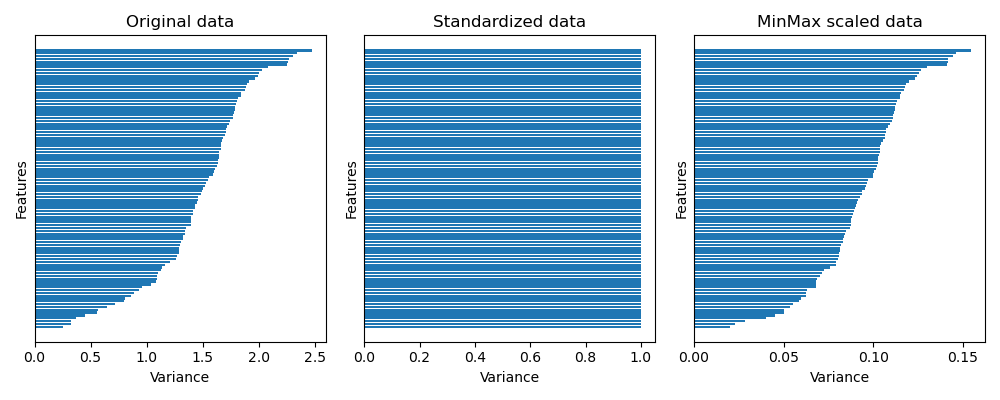

In [6]:
scaler = StandardScaler()
minmax = MinMaxScaler()

Xstd_df = pd.DataFrame(scaler.fit_transform(X_df), columns=X_df.columns)
Xmm_df = pd.DataFrame(minmax.fit_transform(X_df), columns=X_df.columns)

fig, axs = plt.subplots(1, 3, figsize = (10, 4))

dfs = [X_df, Xstd_df, Xmm_df]
titles = ['Original data', 'Standardized data', 'MinMax scaled data']

for title, df, ax in zip(titles, dfs, axs):
    var_s = df.var().sort_values()
    ax.barh(var_s.index, var_s.values)
    ax.set_yticks([])
    ax.set_title(title)
    ax.set_xlabel("Variance")
    ax.set_ylabel("Features")

plt.tight_layout()
plt.show()


Variance of features in pre-processed data depends on the type of pre-processing they are subject to:
- features of *standardized data*, as expected, have unit variance due to the standardization process they've gone through;
- features of *MinMax scaled data* have a variance whose shape resembles the shape of variance of the features of the original data; however being features rescaled in the range $(0,\,1)$ their variance is scaled by a factor that depends on the square of the range the feature covered before being standardized:
$$
\begin{aligned}
\sigma^2 &= \sum_{i=1}^n (x_i - \bar{x})^2 \\
\sigma_{mm}^2 &= \sum_{i=1}^n\left(\frac{x_i - x_{min} - \bar{x} + x_{min}}{x_{max} - x_{min}}\right)^2 = \frac{\sigma^2}{R^2}
\end{aligned}
$$
where $R = x_{max} - x_{min}$ is the length of the range covered by the feature.
Since most features cover the same range (1 to 5) their variance decreases by similar factors, hence the resulting shape is similar.

In the following code cell we show that 94 features over 99 have values ranging from 1 to 5, hence range $R$ is 4 for most features.

In [7]:
pd.DataFrame([X_df.min(), X_df.max()]).T.apply(lambda x: (x[0], x[1]), axis=1).value_counts()

(1, 5)    94
(0, 3)     2
(1, 3)     1
(0, 2)     1
(2, 5)     1
Name: count, dtype: int64

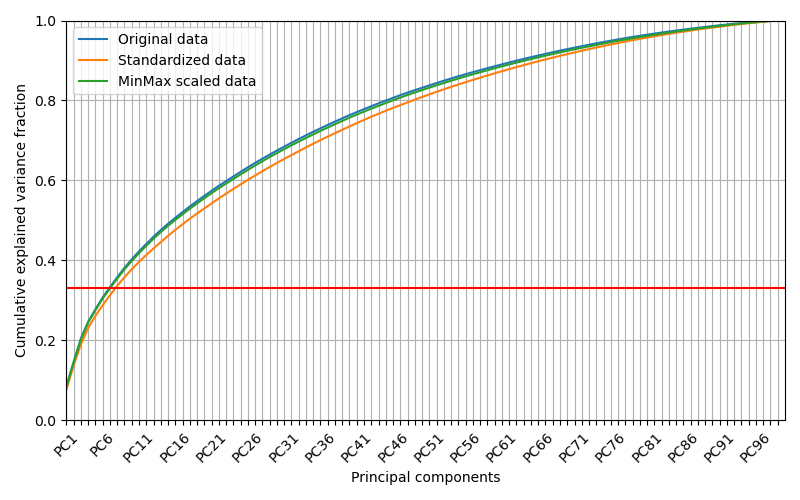

In [8]:
pca_x_df = PCA()
pca_xmm_df = PCA()
pca_xstd_df = PCA()

pca_x_df.fit(X_df.values)
pca_xmm_df.fit(Xmm_df.values)
pca_xstd_df.fit(Xstd_df.values)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
pca_objs = [pca_x_df, pca_xstd_df, pca_xmm_df]

for pca_obj, title in zip(pca_objs, titles):
    ax.plot(np.cumsum(pca_obj.explained_variance_ratio_), label=title)

ax.set_xlabel('Principal components')
ax.set_ylabel('Cumulative explained variance fraction')
ax.set_ylim(0, 1)
ax.set_xlim(0, pca_obj.n_features_in_)
# Set ticks and labels
ax.set_xticks(np.arange(pca_obj.n_features_in_))
PCs_labels=[f'PC{i + 1}' for i in range(pca_obj.n_features_in_)]
[l.set_visible(False) for (i,l) in enumerate(ax.xaxis.get_ticklabels()) if i % 5 != 0]
ax.set_xticklabels(PCs_labels, rotation=45, ha='center', label = title)
ax.grid()
ax.legend()
# Draw a line corresponding to the threshold of the following exercise
ax.axhline(0.33, c='r')

fig.tight_layout()

In the previous figure, one can notice that the curves are similar for original data and MinMax scaled data: this is due to the considerations that were previously made for the distribution of variances among the features of data undergoing different preprocessing steps.
- For *Standardized data*, variance is more evenly distributed across features.
- For *MinMax scaled data*, being the variance of features rescaled by a factor that is the same for pretty much all the features, the same features as in the original data explain most of the variation in the data.

## Exercise 3. Dimensionality Reduction and PC Interpretation

In the cells below, do the following operations:
1. For each one of the two dataframes _Xstd_df_, and _Xmm_df_, compute a new PCA for performing a dimensionality reduction with respect to $m$ dimensions. The value of $m$ must be $$m = \min\{m', 5\}\,,$$ where $m'$ is the value required for obtaining $33\%$ of the total variance.
2. For both the cases, visualize all the PCs and give a name/interpretation to them. **Comment and motivate your interpretations**. If possible, **compare the differences among the results obtained** for _Xstd_df_ and _Xmm_df_.
3. Perform the score graph for both the cases (_std_ and _mm_). If $m>3$, plot the score graph with respect to the first 3 PCs. All the **plots must show the names of the PCs on the axes** for better understanding the results.
4. **Optional:** plot more score graphs, coloring the dots with respect to any label in the list _labels_ that you believe can be interesting. **Comment and analyze this optional plots**.

In [9]:
threshold = 0.33

m_xmm_threshold = (np.cumsum(pca_xmm_df.explained_variance_ratio_) < threshold).sum() + 1
m_std_threshold = (np.cumsum(pca_xstd_df.explained_variance_ratio_) < threshold).sum() + 1

m_xmm = min(m_xmm_threshold, 5)
m_std = min(m_std_threshold, 5)
m_xmm, m_std

(5, 5)

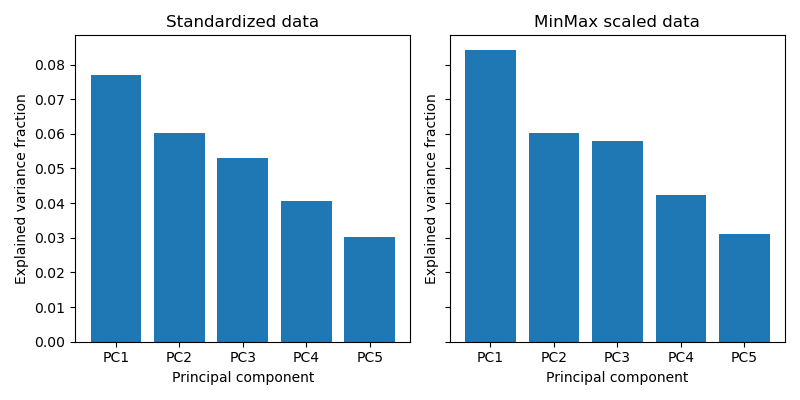

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
for pca_obj, m, title, ax in zip([pca_xstd_df, pca_xmm_df, ], [m_std, m_xmm], titles[1:], axs):
    PCs_labels = [f'PC{i + 1}' for i in range(m)]
    x = np.arange(m)
    ax.bar(x, height=pca_obj.explained_variance_ratio_[:m])
    ax.set_xticks(x)
    ax.set_xticklabels(PCs_labels)
    ax.set_title(title)
    ax.set_xlabel("Principal component")
    ax.set_ylabel("Explained variance fraction")
plt.tight_layout()

In [11]:
def get_question(feature_name):
    columns = pd.read_csv('columns_hw.csv', header=None)
    columns['question'] = columns[0].apply(lambda x: x.split(',')[0])
    columns['name'] = columns[0].apply(lambda x: x.split(',')[1])
    columns = columns.drop(columns=[0])
    return columns.loc[columns['name'] == feature_name]['question']

To better understand the PCA analysis, we color the bars of the attributes according to the category of the feature. This visualization helps us identify patterns and relationships between features and categories more clearly, enhancing the interpretability of the PCA results.  


In [12]:
set2 = cm.Set2.colors

type_colors = {
    'Personality': set2[0],
    'Health': set2[1],
    'Finance': set2[2],
    'Interests': set2[3],
    'Music': set2[4]
}

these_types_col = []
for t in these_types:
    if t != 'Personality':
        these_types_col += [t]*len(variables_by_type[t])
    else:
        these_types_col += [t]*int(2 * (len(variables_by_type[t]) / 3))  

types_df = pd.DataFrame()
types_df['type'] = these_types_col
types_df['feature'] = these_features
types_df['color'] = types_df['type'].apply(lambda x: type_colors[x]) 

In [13]:
def plot_feature_contribution_pc(X, pca, ii, ax, title, eps_coefficient=1, verbose=False):

    eps = eps_coefficient * np.sqrt(1 / pca.n_features_in_)
    color_types = types_df['color']
    type_colors_legend = [Line2D([0], [0], color=type_colors[k])
                          for k in type_colors.keys()]

    ax.barh(np.arange(pca.n_features_in_),
            pca.components_[ii, :], color=color_types)
    # --- RED LINE DENOTING THE THRESHOLD [-eps, +eps] -----------------
    ax.plot([eps, eps], [-0.5, pca.n_features_in_ - 0.5], 'red')
    ax.plot([-eps, -eps], [-0.5, pca.n_features_in_ - 0.5], 'red')
    # ------------------------------------------------------------------
    ax.set_yticks(ticks=np.arange(pca.n_features_in_),
                  labels=X.columns.to_list())
    ax.set_xlim(-0.275, 0.275)
    ax.set_ylim(ax.get_yticks()[0] - 0.5, ax.get_yticks()[-1] + 0.5)
    ax.set_title(f'PC{ii+1} - {title}')
    ax.grid()
    ax.legend(type_colors_legend, [k for k in type_colors.keys()], loc="lower right")


    # THE SELECTION OF THE FEATURES WITH CONTRIBUTE GREATER THAN THE THRESHOLD
    ind_great_pos_PCii = np.argwhere(
        pca.components_[ii, :] >= eps).flatten()
    ind_great_neg_PCii = np.argwhere(
        pca.components_[ii, :] <= -eps).flatten()
    
    for i in ind_great_pos_PCii:
        ax.get_yticklabels()[i].set_color('r')
    for i in ind_great_neg_PCii:
        ax.get_yticklabels()[i].set_color('b')

    great_pos_PCii = [X.columns[i] for i in ind_great_pos_PCii]
    great_neg_PCii = [X.columns[i] for i in ind_great_neg_PCii]
    if verbose:
        print('')
        print(f'****************** PC{ii+1} **********************')
        print(f'HIGH-VALUED POSITIVE COMPONENTS: {great_pos_PCii}')
        print('')
        print(f'HIGH-VALUED NEGATIVE COMPONENTS: {great_neg_PCii}')
        print('*********************************************')
        print('')

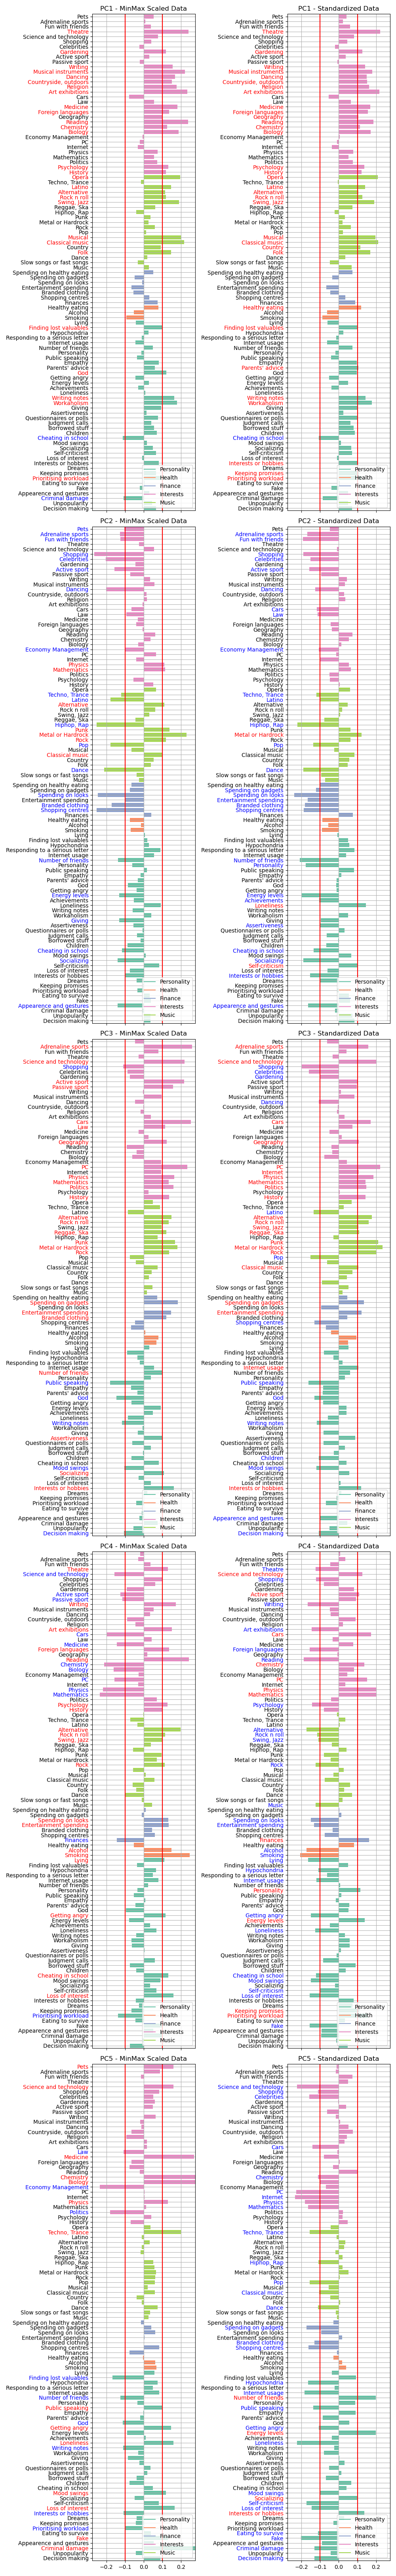

In [14]:
fig, axs = plt.subplots(5, 2, figsize=(10, 65), sharex=True)
for i, ax in enumerate(axs[:,0]):
    plot_feature_contribution_pc(Xmm_df, pca_xmm_df, i, ax, "MinMax Scaled Data")
for i, ax in enumerate(axs[:,1]):
    plot_feature_contribution_pc(Xstd_df, pca_xstd_df, i, ax, "Standardized Data")
fig.tight_layout()

The discussion on the interpretation of the PCs is postponed to the following sections.
We now compare the contribution of the features to the principal components that arise from data being scaled according to MinMax or standardized:
1. (PC1) The contribution of the features are similar.
2. (PC2) The shapes are similar, but standardized data's feature that positively contribute have a lower importance.
3. (PC3) The contribution of the features are similar.
4. (PC4) The contribution of the features are similar, but one is the opposite of the other.
5. (PC5) This is the only PC where the contribution of the features are different.

### MinMax Scaled Data

For MinMax scaled data the following interpretations are given for the first 5 principal components.
1. *Transgression vs. Culture*:
    - (+) Interest in many areas of culture, interest in music genres that are commonly associated with culture, healthy behaviours, personality traits that suggest diligence;
    - (-) Personality traits that suggest criminal behaviour;
2. *Pop vs. Alternative*:
    - (+) Interest in alternative music, interest in STEM;
    - (-) Interest in social activities, carefree spending patterns, interest in commercial music, personality traits of an extrovert;
3. *Introvert vs. Tech Enthusiast*:
    - (+) Interest in STEM, carefree spending patterns, focused on interest and hobbies;
    - (-) Personality traits of an introvert;
4. *Analytical vs. Creative*:
    - (+) Artsy interests, bad health behaviours;
    - (-) Interest in STEM, interest in finance, prioritizes workload;
5. *Social Sciences vs. Life Sciences*:
    - (+) Interest in life sciences;
    - (-) Interest in social sciences.

In [15]:
pc_names_xmm = ['Transgression vs. Culture',
               'Pop vs. Alternative',
               'Introvert vs. Tech Enthusiast',
               'Quantitative Reasoning vs. Humanist Culture',
                'Social Sciences vs. Life Sciences']

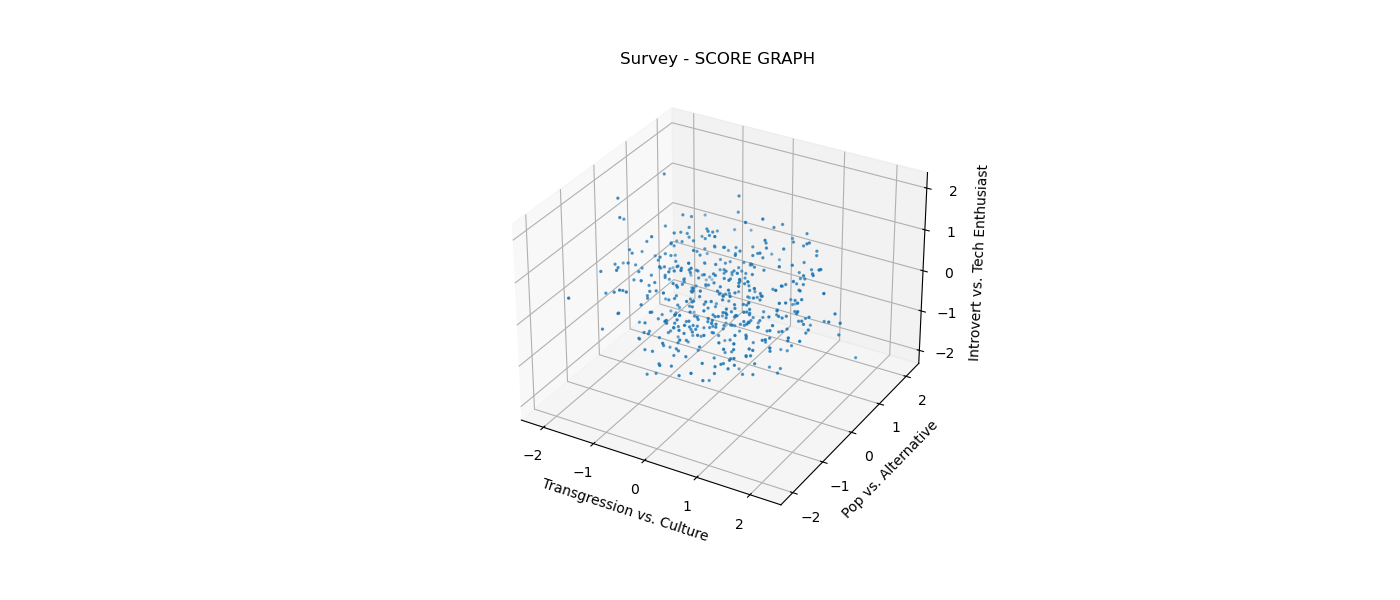

In [16]:
Y_mm = pca_xmm_df.transform(Xmm_df.values)  


# MAKE THE 3D SCORE GRAPH
sg_3d = plt.figure(figsize=(14,6))
ax_sg_3d = sg_3d.add_subplot(111, projection='3d')
ax_sg_3d.scatter(Y_mm[:, 0], Y_mm[:, 1], Y_mm[:, 2], s=2) 
plt.title('Survey - SCORE GRAPH')

ax_sg_3d.set_xlabel(pc_names_xmm[0])
ax_sg_3d.set_ylabel(pc_names_xmm[1])
ax_sg_3d.set_zlabel(pc_names_xmm[2])
plt.grid()
plt.show()
plt.tight_layout()

In [17]:
df_label = selected_columns_labels_df.loc[:, labels]

def plot_score_graph_2D(field, Y, pc_names, alpha=1):
    types = df_label[field].unique()
    cmap = plt.get_cmap('viridis')
    colors = cmap(np.linspace(0, 1, types.size))
    color_dict = {type: color for type, color in zip(types, colors)}
    color_series = df_label[field].apply(lambda x: color_dict[x])
    colors_legend = [Line2D([0], [0], color=k) for k in color_dict.values()]

    # MAKE THE 3D SCORE GRAPH
    fig, ax = plt.subplots()
    ax.scatter(Y[:, 0], Y[:, 1],  s=20, c=color_series.values, alpha=alpha)

    ax.set_xlabel(pc_names[0])
    ax.set_ylabel(pc_names[1])

    ax.grid()
    ax.legend(colors_legend, [k for k in color_dict.keys()])
    plt.tight_layout()
    plt.show()
    return ax

def plot_score_graph(field, Y, pc_names, alpha=1):
    types = df_label[field].unique()
    cmap = plt.get_cmap('viridis')
    colors = cmap(np.linspace(0, 1, types.size))
    color_dict = {type: color for type, color in zip(types, colors)}
    color_series = df_label[field].apply(lambda x: color_dict[x])
    colors_legend = [Line2D([0], [0], color=k) for k in color_dict.values()]

    # MAKE THE 3D SCORE GRAPH
    sg_3d = plt.figure(figsize=(10,6))
    ax_sg_3d = sg_3d.add_subplot(111, projection='3d')
    ax_sg_3d.scatter(Y[:, 0], Y[:, 1], Y[:, 2], s=10, c=color_series.values, alpha=alpha)

    ax_sg_3d.set_xlabel(pc_names[0])
    ax_sg_3d.set_ylabel(pc_names[1])
    ax_sg_3d.set_zlabel(pc_names[2])

    plt.grid()
    plt.legend(colors_legend, [k for k in color_dict.keys()])
    plt.title(field)
    plt.tight_layout()
    plt.show()
    return ax_sg_3d

In order to plot score graphs where points are colored according to a certain label, since many labels have lots of different values and we want to avoid using too many colours which may make the figures difficult to read, we split continuous features or features which have too many categorical values into ranges.

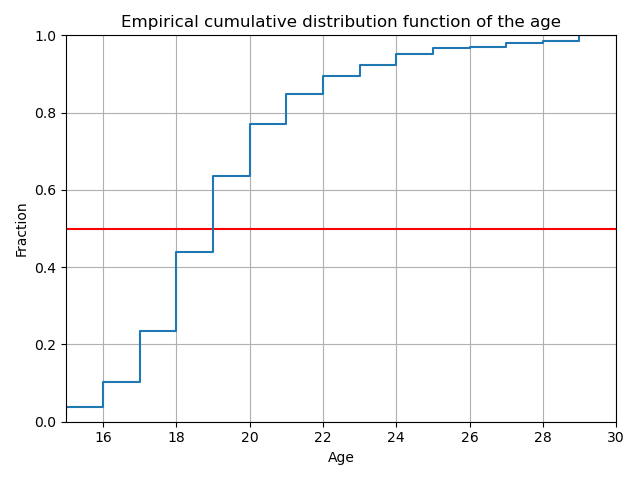

In [18]:
age = df_label['Age']

age = age.value_counts()


fig, ax = plt.subplots()


ax.axhline(0.5, c='red')
ax.plot(np.sort(df_label['Age'].unique()), age.sort_index().values.cumsum()/age.sort_index().values.sum(), drawstyle='steps')
ax.grid(visible=True)
ax.set_ylim(0, 1)
ax.set_xlim(df_label['Age'].min(), df_label['Age'].max())
ax.set_xlabel('Age')
ax.set_ylabel('Fraction')
ax.set_title('Empirical cumulative distribution function of the age')
plt.tight_layout()
plt.show()


Having plotted the empirical cumulative distribution of the ages, we chose to split ages in two ranges: age less or equal than 20 and age greater than 20 since 20 is the median age.

In [40]:
df_label['AgeGt20'] = df_label.Age.apply(lambda x: "<= 20" if x <= 20 else "> 20")

Since height and weight did not show any particular pattern with respect to the 3 first principal components, we chose to compute the BMI and to assign labels to distinct ranges of the BMI.

In [41]:
def get_bmi_label(bmi):
    if bmi <= 18.5:
        return "Thinness"
    elif bmi <= 25:
        return "Ideal Weight"
    elif bmi <= 30:
        return "Overweight"
    return "Obese"


arr = np.array(df_label.values[:,:3], dtype=np.float32)
df_label['BMI'] = arr[:,2]/np.square(arr[:,1]/100)
df_label['BMI Label'] = df_label['BMI'].apply(get_bmi_label)

Since education had lots of distinct labels that were not so meaningful, we chose to group them into the following ranges:
- *undergrad*, for people who did not continue studies past college;
- *degree*, for people who continued studies past college.

In [ ]:
def get_education_label(education):
    if education in ['college/bachelor degree', 'masters degree', 'doctorate degree']:
        return 'degree'
    return "undergrad"

df_label['Education label'] = df_label['Education'].apply(get_education_label)

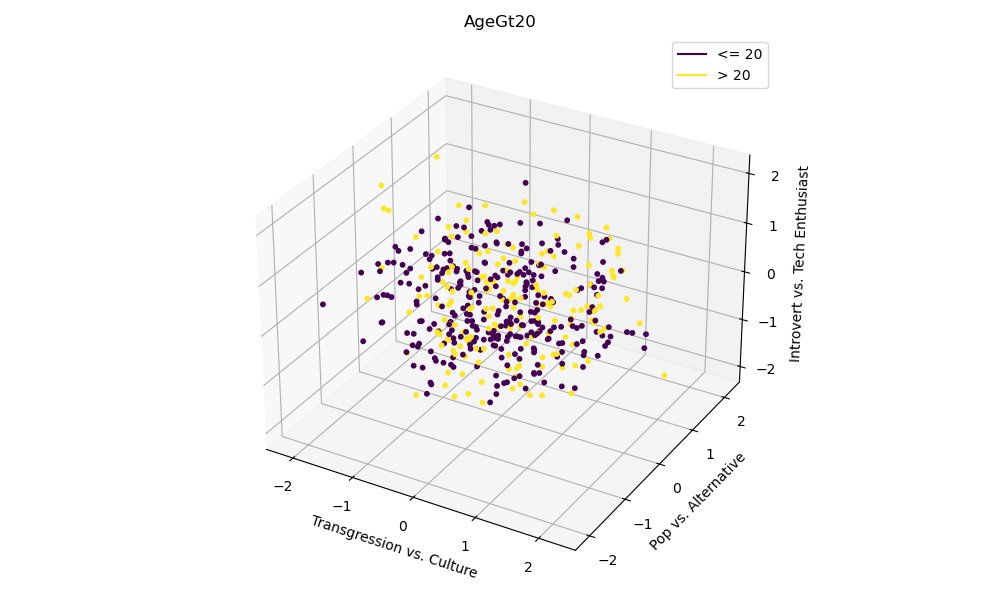

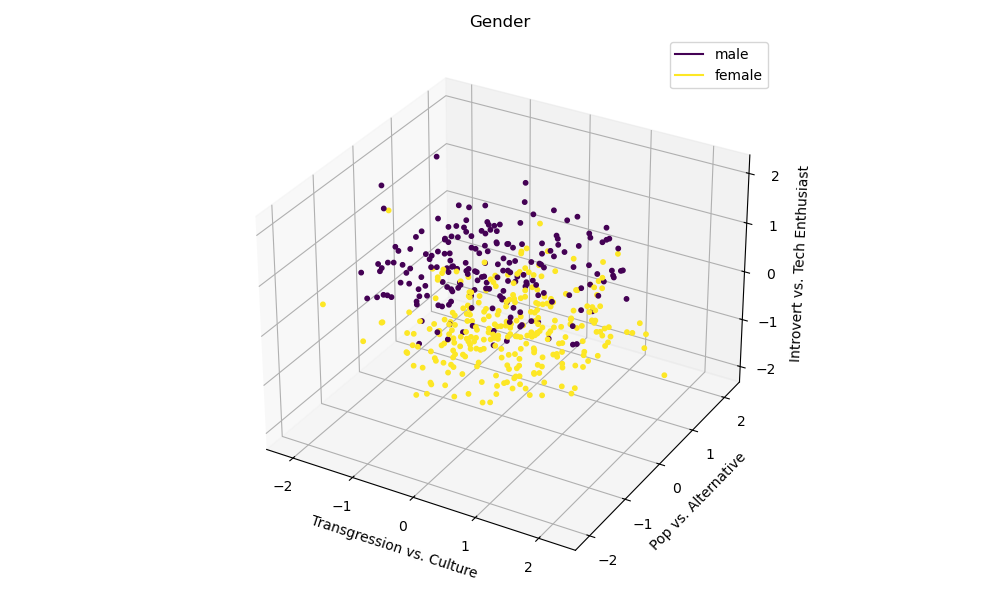

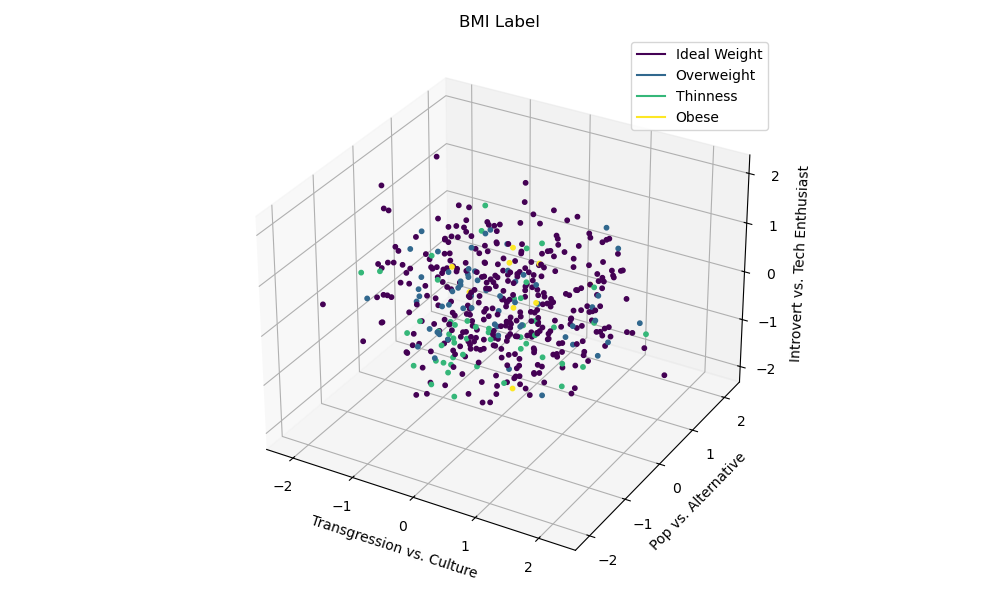

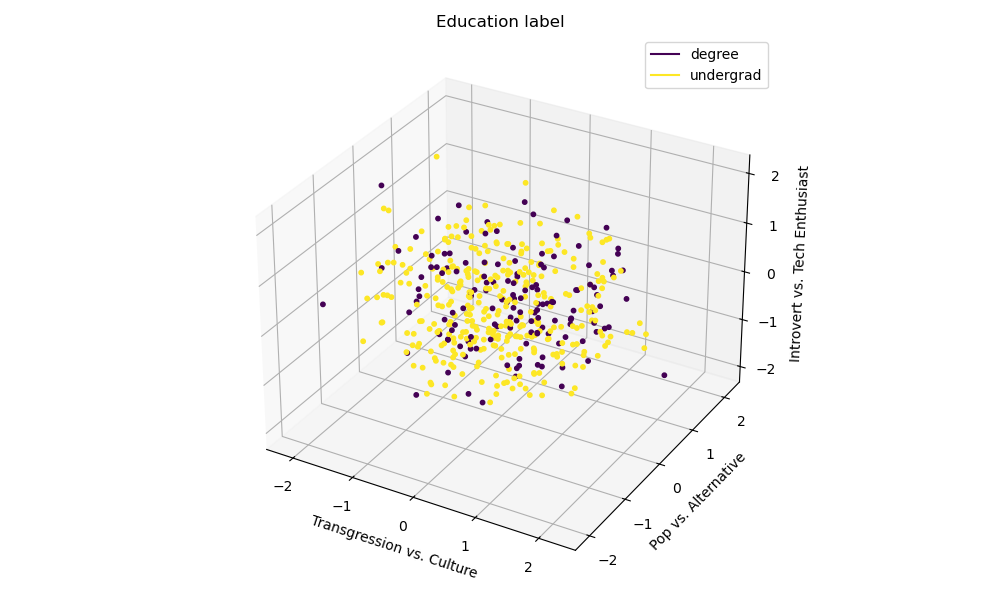

<Axes3D: title={'center': 'Education label'}, xlabel='Transgression vs. Culture', ylabel='Pop vs. Alternative', zlabel='Introvert vs. Tech Enthusiast'>

In [45]:
plot_score_graph('AgeGt20', Y_mm, pc_names_xmm)
plot_score_graph('Gender', Y_mm, pc_names_xmm)
plot_score_graph("BMI Label", Y_mm, pc_names_xmm)
plot_score_graph('Education label', Y_mm, pc_names_xmm)

### Standardized Data

For standardized data the following interpretations are given for the first 5 principal components.
1. *Transgression vs. Culture*:
    - (+) Interest in many areas of culture, interest in music genres that are commonly associated with culture, healthy behaviours, personality traits that suggest diligence;
    - (-) Personality traits that suggest criminal behaviour;
2. *Extrovert vs. Introvert*:
    - (+) Feelings of loneliness and self-criticism, interest in Metal music;
    - (-) Interest in social activities, carefree spending patterns, interest in commercial music, personality traits of an extrovert;
3. *Pop vs. Alternative*:
    - (+) Interest in alternative music, interest in STEM;
    - (-) Interest in social activities, carefree spending patterns, interest in commercial music;
4. *Creative vs. Analytical*:
    - (+) Interest in STEM, interest in finance, prioritizes workload;
    - (-) Artsy interests, bad health behaviours;
5. *Modern Recluse vs. Social Butterfly*:
    - (+) Personality traits of an extrovert;
    - (-) Geeky interests, loneliness, high usage of internet, carefree spending habits.

In [23]:
pc_names_std = [
    'Transgression vs. Culture',
    'Extrovert vs. Introvert',
    'Pop vs. Alternative',
    'Analytical vs. Creative',
    'Modern recluse vs. Social butterfly'
]

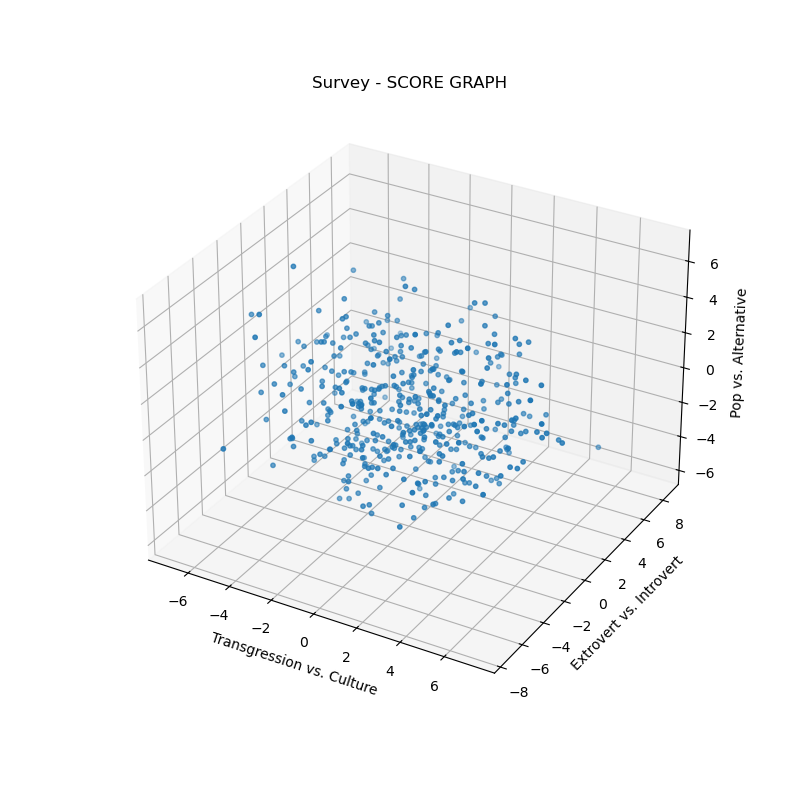

In [24]:
Y_std = pca_xstd_df.transform(Xstd_df.values)  

# MAKE THE 3D SCORE GRAPH
sg_3d = plt.figure(figsize=(8, 8))
ax_sg_3d = sg_3d.add_subplot(111, projection='3d')
ax_sg_3d.scatter(Y_std[:, 0], Y_std[:, 1], Y_std[:, 2], s=10) 
plt.title('Survey - SCORE GRAPH')
ax_sg_3d.set_xlabel(pc_names_std[0])
ax_sg_3d.set_ylabel(pc_names_std[1])
ax_sg_3d.set_zlabel(pc_names_std[2])
plt.grid()
plt.show()

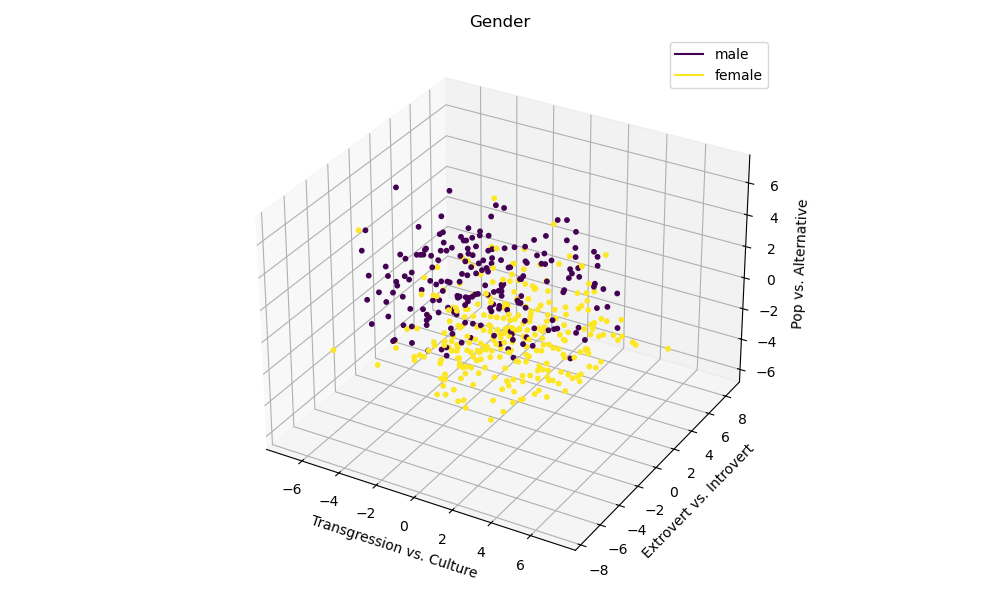

<Axes3D: title={'center': 'Gender'}, xlabel='Transgression vs. Culture', ylabel='Extrovert vs. Introvert', zlabel='Pop vs. Alternative'>

In [25]:
plot_score_graph('Gender', Y_std, pc_names_std)

## Exercise 4. $k$-Means

In the cells below, do the following operations:
1. For each one of the two datasets (_std_ and _mm_), run the $k$-Means for clustering the data. In particular, **use the silohuette score for identify the best value for $k\in\{3, \ldots, 10\}$**.
2. Plot the score graphs of exercise 3.3, adding the centroids of the cluster.
3. Observing the centroids coordinates in the PC space, **give a name/interpretation to them**, exploiting the names you assigned to the PCs. **Comment and motivate your interpretations**.

In [37]:
random_state = random_seed

def best_k(Y, verbose=False):
    # INITIALIZE SOME LISTS TO STORE THE TEMPORARY RESULTS AND, THEN, MAKE COMPARISONS
    km_list = []
    silcoeff_list = []
    k_list = list(range(3, 11))

    # START THE FOR-CYCLE TO RUN THE k-MEANS AND MEASURING THE SILHOUETTE COEFFICIENT
    for i in range(len(k_list)):
        if verbose:
            print(f'****************** START k-MEANS WITH k={k_list[i]} ******************')
            print('Computing...')
        km_list.append(KMeans(k_list[i]))  
        km = km_list[i]
        # attenzione il fit va fatto sui dati trasformati con il pca

        km.fit(Y)
        silcoeff_list.append(silhouette_score(Y, km.predict(Y)))
        if verbose:
            print(f'****************** END k-MEANS WITH k={k_list[i]} ******************')
            print('')

    # FIND THE BEST VALUE OF k AND THE BEST KMeans OBJECT
    i_best = np.argmax(silcoeff_list) 
    k = k_list[i_best]
    km = km_list[i_best]

    # VISUALIZE THE RESULT
    if verbose:
        print('')
        print('')
        print('****************** RESULTS OF THE SEARCH... ******************')
        print(f'BEST SILHOUETTE SCORE: {np.max(silcoeff_list)} --> k = {k}') 
        print('**************************************************************')
    return k, km, k_list, silcoeff_list

def plot_sil_score(k_list, silcoeff_list):
    plt.figure()
    plt.plot(k_list, silcoeff_list)
    plt.grid(visible=True)
    plt.xlabel('k')
    plt.ylabel('Silhouette score')
    plt.title('Silhouette Scores for Different Values of k')
    plt.xlim(min(k_list), max(k_list))
    plt.show()

def plot_score_graph_cluster(field, Y, pc_names, k, km):
    
    ax_sg_3d = plot_score_graph(field, Y, pc_names, 0.3)

    for kk in range(k):
        ax_sg_3d.text(km.cluster_centers_[kk, 0], km.cluster_centers_[kk, 1], km.cluster_centers_[kk, 2], f'clust.{kk + 1}')
    ax_sg_3d.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], km.cluster_centers_[:, 2], color='black', alpha=1)
    return 

def plot_score_graph_cluster_2D(field, Y, pc_names, k, km):
    
    ax = plot_score_graph_2D(field, Y, pc_names, 0.3)

    for kk in range(k):
        ax.text(km.cluster_centers_[kk, 0], km.cluster_centers_[kk, 1],  f'clust.{kk + 1}')
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],  color='black', alpha=1)
    return




### minmax

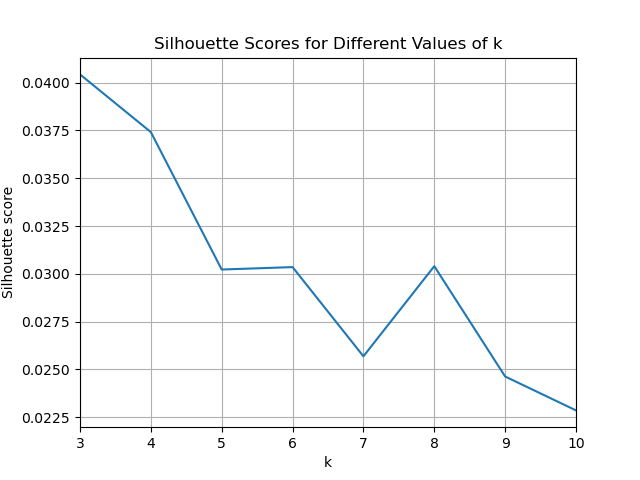

In [38]:
k_mm, km_mm, k_list_mm, silcoeff_list_mm = best_k(Y_mm)
plot_sil_score(k_list_mm, silcoeff_list_mm)

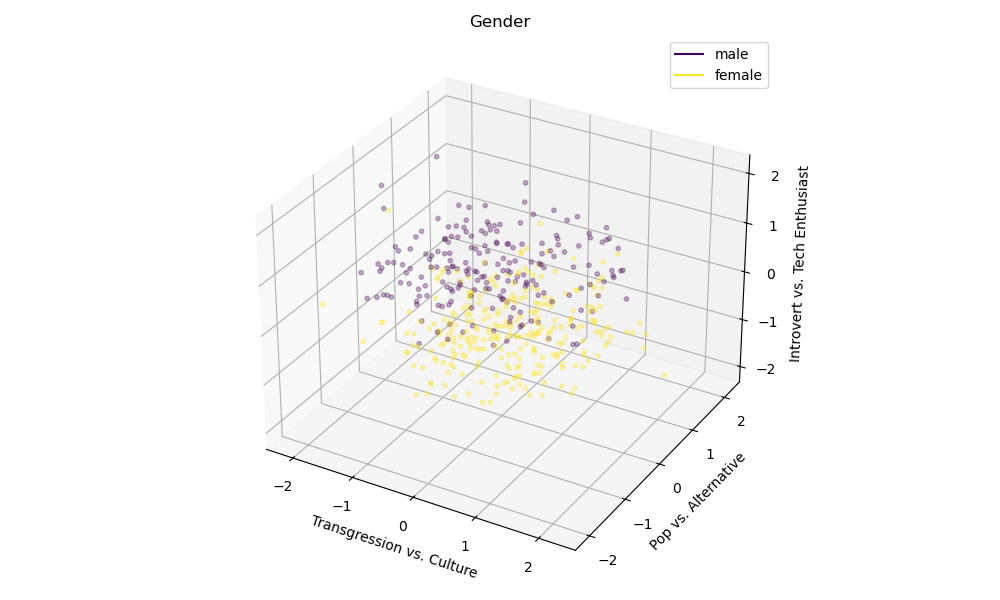

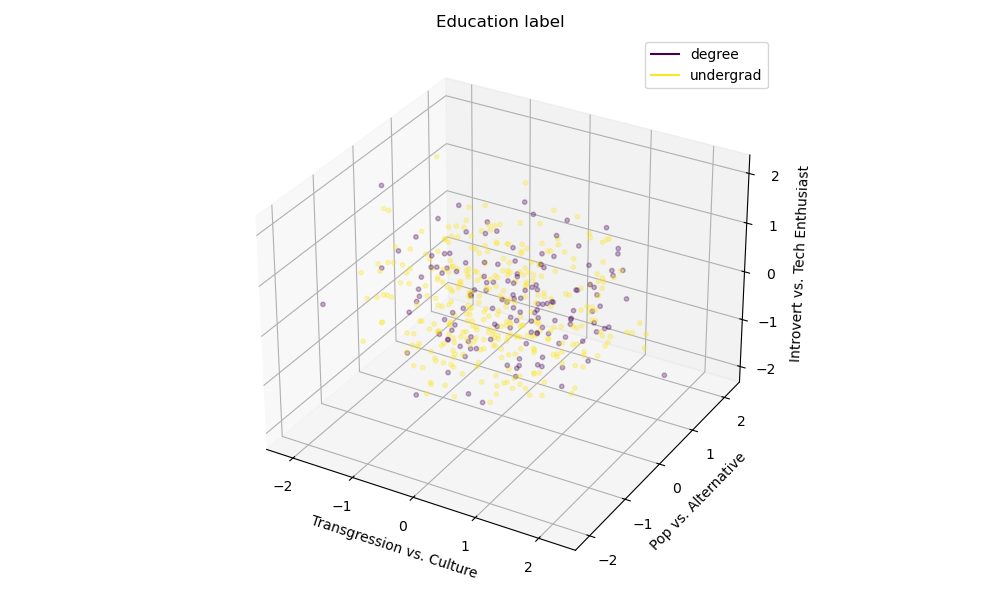

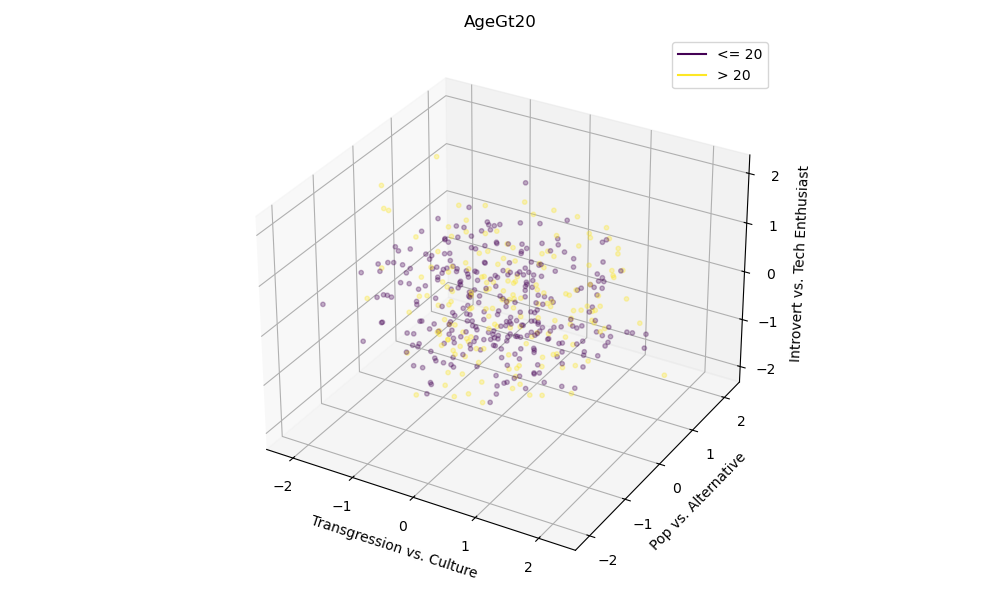

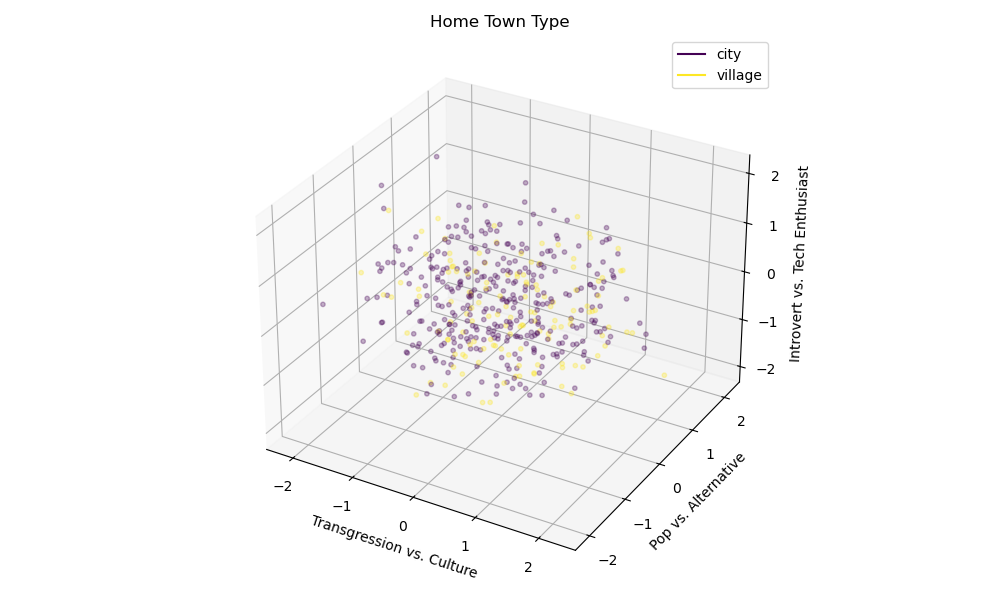

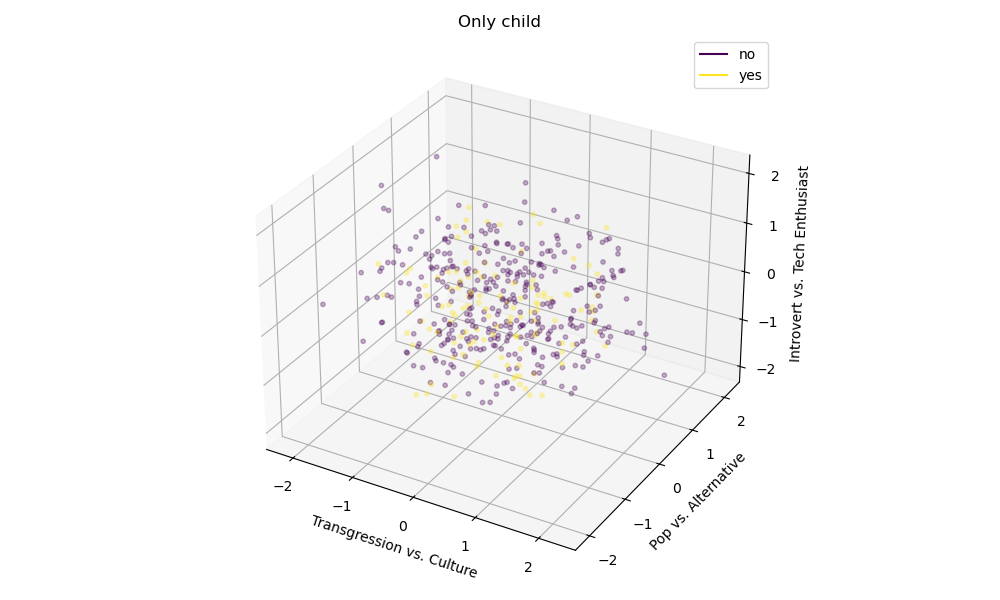

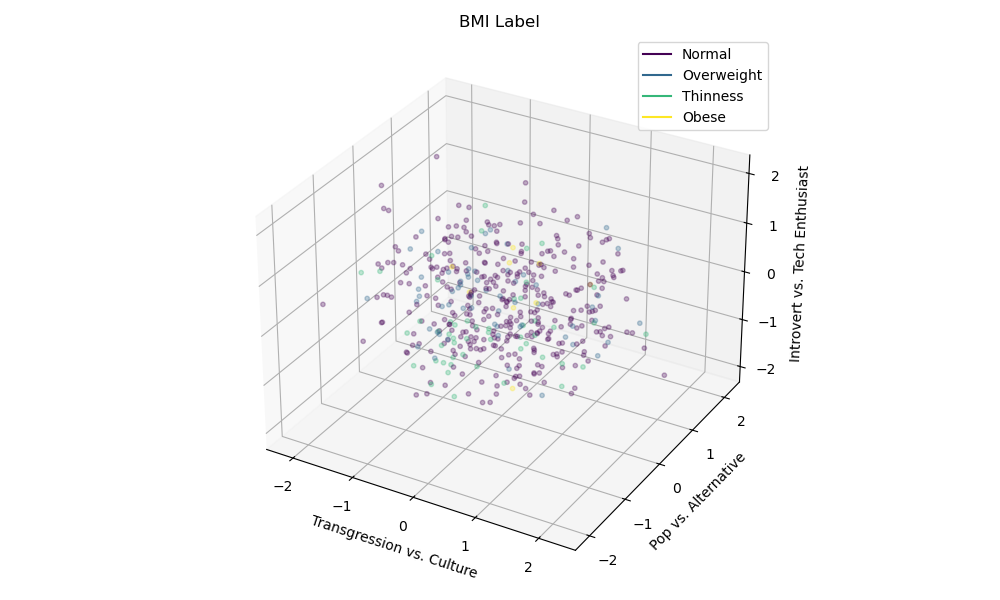

In [28]:
plot_score_graph_cluster('Gender', Y_mm, pc_names_xmm, k_mm, km_mm)
plot_score_graph_cluster('Education label', Y_mm, pc_names_xmm, k_mm, km_mm)
plot_score_graph_cluster('AgeGt20', Y_mm, pc_names_xmm, k_mm, km_mm)
plot_score_graph_cluster('Home Town Type', Y_mm, pc_names_xmm, k_mm, km_mm)
plot_score_graph_cluster('Only child', Y_mm, pc_names_xmm, k_mm, km_mm)
plot_score_graph_cluster('BMI Label', Y_mm, pc_names_xmm, k_mm, km_mm)

### Std

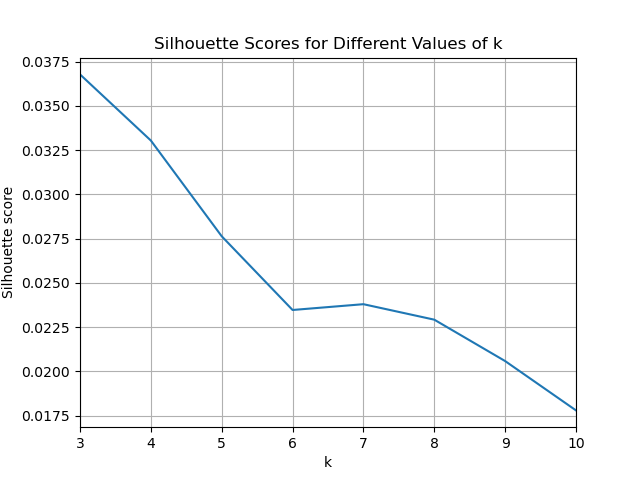

In [29]:
k_std, km_std, k_list_std, silcoeff_list_std = best_k(Y_std)
plot_sil_score(k_list_std, silcoeff_list_std)

## Exercise 5. Cluster Evaluations

In the cells below, do the following operations:
1. For each one of the two datasets (_std_ and _mm_), perform an **external evaluation** of the clustering obtained at exercise 4.1 with respect to one or more labels in the list _labels_. **Comment the results, comparing the evaluation with the interpretation you gave at exercise 4.3**. 
2. For each one of the two datasets (_std_ and _mm_), perform an **internal evaluation** of each cluster, with respect to the silohuette score. **Comment the results**. 

In [30]:
def external_evaluation(Y, k, km, field, cluster_names):

    df_cluster = pd.DataFrame(km.predict(Y), columns=['cluster'], dtype=np.int16)
    df_cluster[field] = df_label[field]

    labels = df_label[field].unique()

    fig, ax = plt.subplots(1, k, figsize=(4*k, 4), sharey=True)
    

    for i in range(k):
        df_cluster_i = dict(df_cluster.loc[df_cluster['cluster'] == i][field].value_counts())
        ax[i].grid(visible = True)
        ax[i].bar(labels, [df_cluster_i.get(l, 0) for l in labels])
        ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha = 'right')
        ax[i].set_title(f'Cluster {i+1} {cluster_names[i]}')
    
    plt.tight_layout()
    plt.show()
    return


def internal_evaluation(cluster_names, Y, k, km):
    sil_scores = silhouette_samples(Y, km.labels_)
    cluster_sil = [sil_scores[km.labels_ == i].mean() for i in range(k)]

    return pd.DataFrame(cluster_sil, index=cluster_names, columns=['sil_score']).sort_values('sil_score', ascending=False)


### External evaluation

### min max

/tmp/ipykernel_2897/379555220.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, k, figsize=(4*k, 4), sharey=True)
/tmp/ipykernel_2897/379555220.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha = 'right')
/tmp/ipykernel_2897/379555220.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha = 'right')
/tmp/ipykernel_2897/379555220.py:15: UserWarning: set_ticklabels() should only be used with a fixed number 

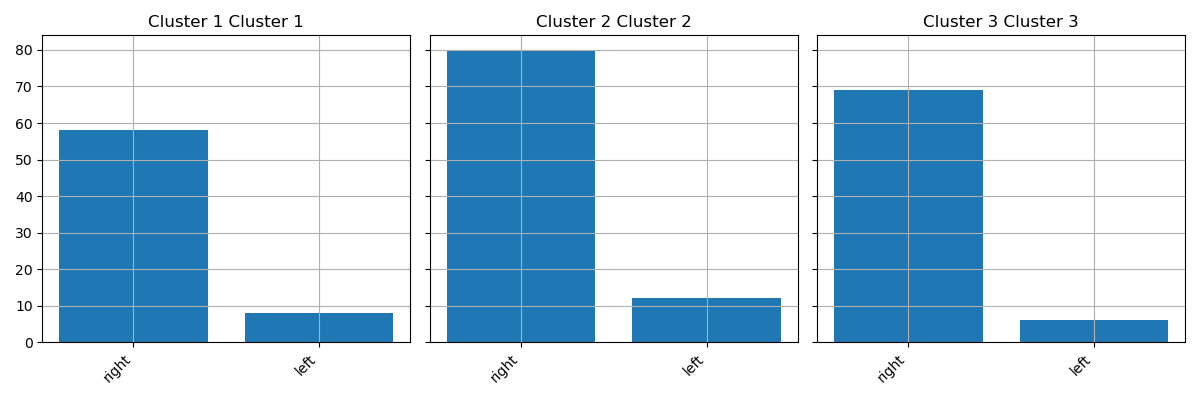

In [31]:
cluster_names_mm = ['Cluster 1', 
                 'Cluster 2', 
                 'Cluster 3'
                ]

external_evaluation(Y_mm, k_mm, km_mm, 'Hand', cluster_names_mm)


In [32]:
df_label.info()

<class 'pandas.core.frame.DataFrame'>
Index: 476 entries, 183 to 35
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 476 non-null    float64
 1   Height              476 non-null    float64
 2   Weight              476 non-null    float64
 3   Number of siblings  476 non-null    float64
 4   Gender              476 non-null    object 
 5   Hand                476 non-null    object 
 6   Education           476 non-null    object 
 7   Only child          476 non-null    object 
 8   Home Town Type      476 non-null    object 
 9   Home Type           476 non-null    object 
 10  AgeGt20             476 non-null    object 
 11  BMI                 476 non-null    float32
 12  BMI Label           476 non-null    object 
 13  Education label     476 non-null    object 
dtypes: float32(1), float64(4), object(9)
memory usage: 70.1+ KB


### Internal Eval

### min max

In [33]:
# LIST OF THE NAMES ASSIGNED TO THE FOUR CLUSTERS

internal_evaluation(cluster_names_mm, Y_mm, k_mm, km_mm)

,sil_score
Cluster 2,0.063602
Cluster 3,0.036906
Cluster 1,0.017505


### std

In [34]:
# LIST OF THE NAMES ASSIGNED TO THE FOUR CLUSTERS
cluster_names_std = ['Cluster 1', 
                 'Cluster 2', 
                 'Cluster 3'
                ]


internal_evaluation(cluster_names_std, Y_std, k_std, km_std)

,sil_score
Cluster 3,0.054471
Cluster 1,0.031601
Cluster 2,0.021784
